# Equipment Failure Risk Model: Technical Walkthrough

Full pipeline: exploratory analysis, a leakage-safe feature pipeline with a temporal split, a class-imbalance-aware classifier evaluated with the right metric for a ~2% unplanned-failure rate, a cost-based decision threshold, SHAP interpretability, and a check on how much a supervised model actually buys over an unsupervised anomaly score. Same methodology family as projects 01 and 05. See the [README](../README.md) for the short version.

> All data here is synthetically generated. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix,
)
import shap

from style import set_style, style_ax, add_footnote, SLATE, MUTED_TEAL, MUTED_AMBER, MUTED_RED, GREY, PALETTE, HEATMAP_CMAP, INK, HEATMAP_TEXT_LOW, HEATMAP_TEXT_HIGH
from features import build_feature_pipeline, temporal_split, RAW_FEATURE_COLS
from train import find_cost_optimal_threshold, UNPLANNED_FAILURE_REPAIR_PREMIUM_USD, SCHEDULED_INSPECTION_COST_USD
from anomaly_detection import fit_isolation_forest, anomaly_scores

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

90k synthetic truck-day telemetry records from a 150-truck open-pit mining fleet over a 600-day window: engine hours, vibration, oil pressure, coolant temperature, brake wear, recent diagnostic fault codes, days since the last preventive-maintenance (PM) service, payload, and site ambient temperature. `failure_within_7d` is generated from a hand-specified risk function over these features plus noise (see `src/generate_data.py`), calibrated to a realistic ~2.2% base rate, not fit from any real fleet.

In [2]:
tx = pd.read_csv("../data/truck_telemetry.csv", parse_dates=["date"])
print(f"{len(tx):,} truck-days, {tx.truck_id.nunique():,} trucks, "
      f"{tx.date.min().date()} to {tx.date.max().date()}")
print(f"Overall unplanned-failure rate: {tx.failure_within_7d.mean():.3%}")
tx.head()

90,000 truck-days, 150 trucks, 2024-01-01 to 2025-08-22
Overall unplanned-failure rate: 2.190%


,truck_id,truck_class,site,date,equipment_age_years_at_obs,engine_hours_at_obs,ambient_temp_c,payload_avg_tons,downtime_cost_usd,days_since_last_pm,vibration_rms_mm_s,oil_pressure_psi,coolant_temp_c,brake_wear_pct,fault_codes_7d,failure_within_7d
0,61,standard_class_200t,east_pit,2025-08-20,4.660407,18921,24.647747,213.1,27013.70,12,3.966,60.2,87.8,0.0,0,0
1,7,standard_class_200t,north_pit,2024-03-24,1.836437,7847,24.894459,203.0,44059.22,42,3.208,48.7,91.6,7.4,1,0
2,4,standard_class_200t,south_pit,2024-12-22,1.726304,8918,37.298529,202.4,24431.35,19,2.135,61.3,89.4,14.2,0,0
3,56,standard_class_200t,north_pit,2025-02-23,5.633621,24101,15.376670,186.3,36808.30,32,4.039,51.8,86.4,13.4,0,0
4,40,standard_class_200t,north_pit,2025-03-18,8.193428,35754,23.668475,178.3,19287.78,32,2.062,61.0,91.0,11.3,0,0


## 2. Exploratory analysis

The imbalance itself comes first: unplanned failure is 2.2% of truck-days, healthy dwarfs it on a linear scale (Figure 1). Every signal the failure label was generated from should also show up as a clear split in the raw failure rate, checked here before any modeling.

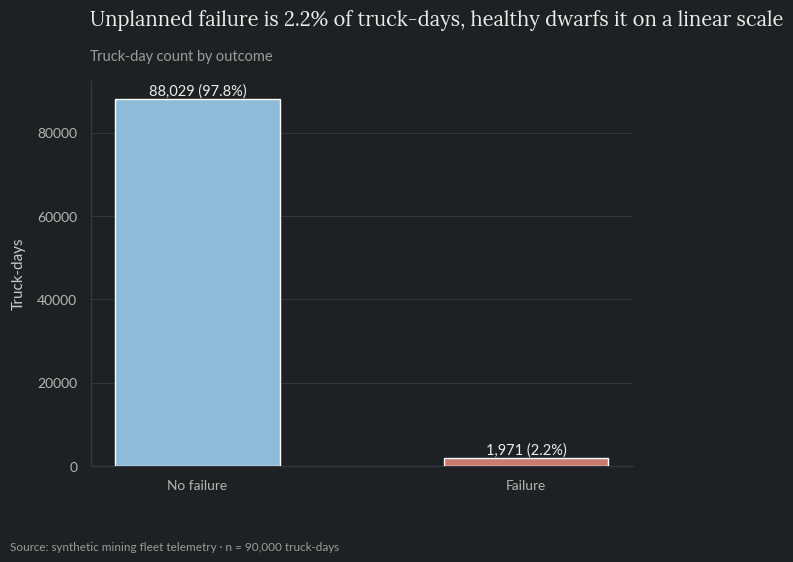

In [3]:
n_healthy = int((tx["failure_within_7d"] == 0).sum())
n_failure = int((tx["failure_within_7d"] == 1).sum())
failure_rate = tx["failure_within_7d"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ["No failure", "Failure"]
vals = [n_healthy, n_failure]
ax.bar(bars, vals, color=[SLATE, MUTED_RED], width=0.5, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + len(tx) * 0.01, f"{v:,} ({v / len(tx):.1%})", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title=f"Unplanned failure is {failure_rate:.1%} of truck-days, healthy dwarfs it on a linear scale",
         subtitle="Truck-day count by outcome",
         ylabel="Truck-days")
add_footnote(fig, f"Source: synthetic mining fleet telemetry · n = {len(tx):,} truck-days")
plt.show()

**Figure 1.** Truck-day count by outcome, no failure vs. failure.

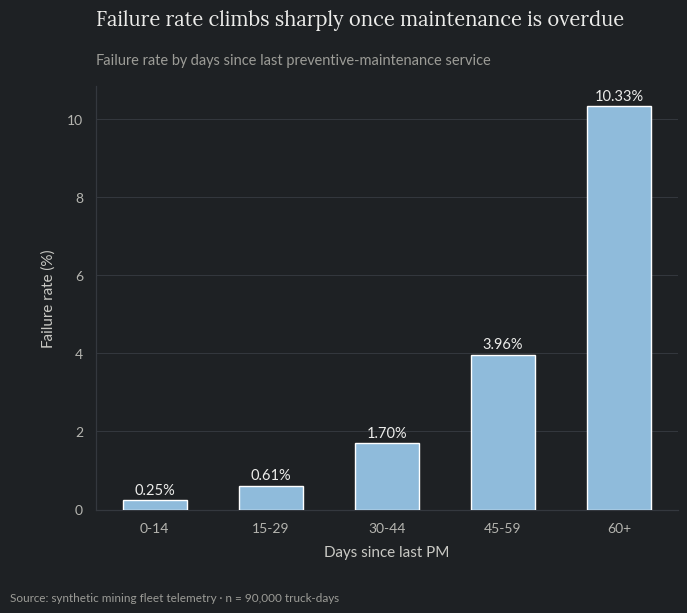

In [4]:
tx["pm_bucket"] = pd.cut(tx["days_since_last_pm"], [-1, 14, 29, 44, 59, 1000],
                          labels=["0-14", "15-29", "30-44", "45-59", "60+"])
fig, ax = plt.subplots(figsize=(7.5, 5.5))
rates = tx.groupby("pm_bucket", observed=True)["failure_within_7d"].mean() * 100
ax.bar(rates.index.astype(str), rates.values, color=SLATE, width=0.55, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.15, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Failure rate climbs sharply once maintenance is overdue",
         subtitle="Failure rate by days since last preventive-maintenance service",
         xlabel="Days since last PM", ylabel="Failure rate (%)")
add_footnote(fig, f"Source: synthetic mining fleet telemetry · n = {len(tx):,} truck-days")
plt.show()

**Figure 2.** Failure rate by days since last preventive-maintenance service.

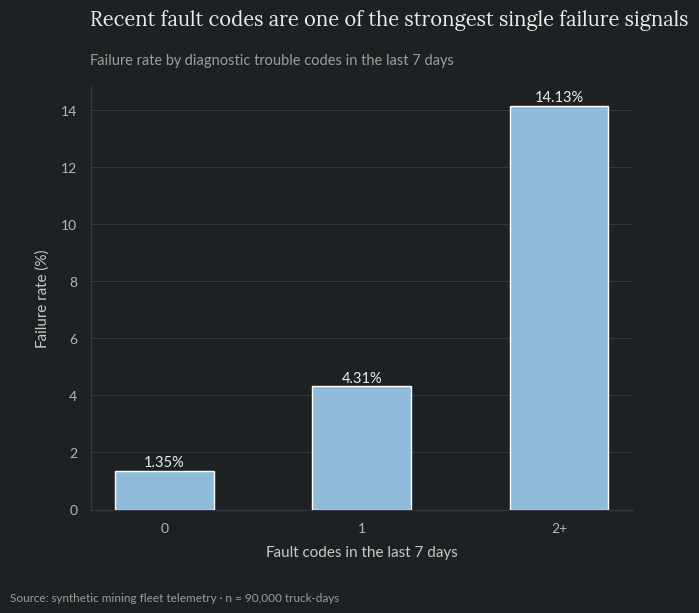

In [5]:
tx["fault_bucket"] = pd.cut(tx["fault_codes_7d"], [-1, 0, 1, 100], labels=["0", "1", "2+"])
fig, ax = plt.subplots(figsize=(7, 5.5))
rates = tx.groupby("fault_bucket", observed=True)["failure_within_7d"].mean() * 100
ax.bar(rates.index.astype(str), rates.values, color=SLATE, width=0.5, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.15, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
style_ax(ax, title="Recent fault codes are one of the strongest single failure signals",
         subtitle="Failure rate by diagnostic trouble codes in the last 7 days",
         xlabel="Fault codes in the last 7 days", ylabel="Failure rate (%)")
add_footnote(fig, f"Source: synthetic mining fleet telemetry · n = {len(tx):,} truck-days")
plt.show()

**Figure 3.** Failure rate by diagnostic trouble codes in the last 7 days.

Both signals move in the expected direction (Figures 2 and 3), and by a wide margin: 60+ days overdue on PM raises the failure rate roughly 40x over a truck serviced in the last two weeks, and two or more fault codes in the last week raises it about 10x over a clean week. Vibration, oil pressure, coolant temperature, and equipment age show the same kind of separation (see `src/generate_data.py` for the full set); the modeling sections below check whether a classifier recovers the full set, beyond the two most obvious ones shown here.

## 3. Feature pipeline and temporal split

No missing values in this dataset (telemetry signals are always available by construction), so the pipeline here is lighter than project 01's: winsorize the long-tailed sensor readings, one-hot encode the two categoricals (truck class, site), fit on the training split only. The split itself is temporal (train on the earlier ~70% of days, validate and test on what comes after), the same rationale as every other project in this repo: a random split would let the model implicitly see the future during training.

In [6]:
train_df, val_df, test_df = temporal_split(tx)
print(f"Train: {len(train_df):,} ({train_df.failure_within_7d.mean():.3%} failure) | "
      f"Val: {len(val_df):,} ({val_df.failure_within_7d.mean():.3%} failure) | "
      f"Test: {len(test_df):,} ({test_df.failure_within_7d.mean():.3%} failure)")

feature_pipeline = build_feature_pipeline()
X_train = feature_pipeline.fit_transform(train_df[RAW_FEATURE_COLS])
X_test = feature_pipeline.transform(test_df[RAW_FEATURE_COLS])
feature_names = list(X_train.columns)
y_train = train_df["failure_within_7d"].values
y_test = test_df["failure_within_7d"].values
print(f"{X_train.shape[1]} features after one-hot encoding")

Train: 63,150 (2.032% failure) | Val: 13,500 (2.504% failure) | Test: 13,350 (2.622% failure)


17 features after one-hot encoding


## 4. Modeling: logistic regression baseline vs. gradient-boosted trees

PR-AUC (average precision) is the headline metric here rather than ROC-AUC: ROC-AUC's false-positive rate is measured against the huge pool of healthy truck-days, so it barely moves even when a model performs badly on the rare failure class, while PR-AUC is computed entirely from precision and recall on the positive class and collapses toward the base rate as soon as ranking quality drops. `class_weight="balanced"` was tried on both models and hurt ranking quality on this dataset (it distorts which splits the trees favor during training, changing the ranking itself rather than only the probability scale), so neither model reweights the training loss here. The class imbalance is instead handled entirely at the decision-threshold stage in section 6, which is where the actual cost asymmetry between a missed failure and a false alarm lives anyway.

In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
logit = LogisticRegression(max_iter=2000)
logit.fit(X_train_s, y_train)
logit_prob = logit.predict_proba(X_test_s)[:, 1]
logit_ap = average_precision_score(y_test, logit_prob)

gbm = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.1, max_iter=300,
                                       min_samples_leaf=40, random_state=42)
gbm.fit(X_train, y_train)
y_prob_test = gbm.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
print(f"Logistic regression baseline PR-AUC: {logit_ap:.4f}")
print(f"GBM ROC-AUC: {auc:.4f} | GBM PR-AUC: {ap:.4f}")

Logistic regression baseline PR-AUC: 0.4337
GBM ROC-AUC: 0.9059 | GBM PR-AUC: 0.4019


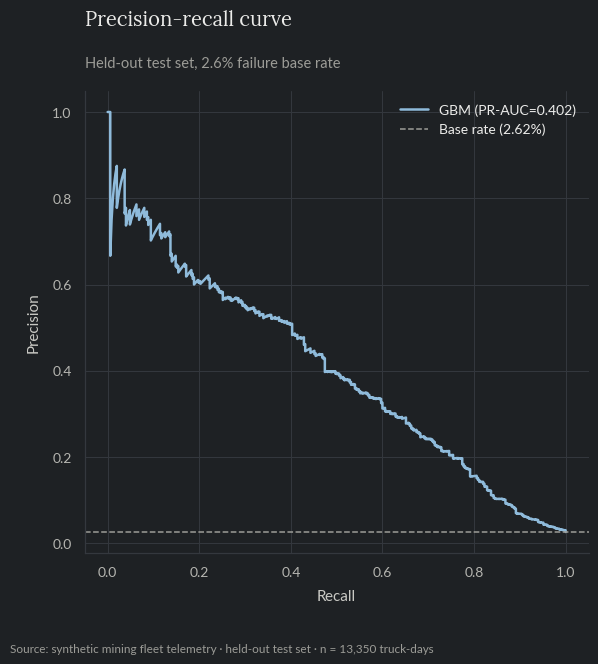

In [8]:
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
base_rate = y_test.mean()
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(rec, prec, color=SLATE, linewidth=1.8, label=f"GBM (PR-AUC={ap:.3f})")
ax.axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Base rate ({base_rate:.2%})")
style_ax(ax, title="Precision-recall curve", subtitle="Held-out test set, 2.6% failure base rate",
         xlabel="Recall", ylabel="Precision", grid_axis="both")
ax.legend(loc="upper right")
add_footnote(fig, f"Source: synthetic mining fleet telemetry · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 4.** Precision-recall curve on the held-out test set, GBM vs. the base rate.

The logistic baseline slightly edges out the GBM on PR-AUC (0.434 vs. 0.402), the reverse of project 05's result. That's a genuine finding, not a bug: the failure label here was generated from a close-to-linear combination of the raw signals (see `src/generate_data.py`), so a linear model captures most of the available signal on its own, and the GBM's extra flexibility to model interactions and nonlinearities buys little on top of it. Both clear the 2.6% base rate by a wide margin (Figure 4), an ~15x lift for the GBM. Real predictive-maintenance systems report PR-AUC in this range at similar imbalance; a PR-AUC near 1.0 at a 2% base rate would be far more likely to indicate a leaked label than a good model. The GBM is still carried forward below for its interpretability tooling (SHAP) and because a production system would keep both models in the comparison rather than lock in the linear one on a single test split.

## 5. Why accuracy is the wrong metric here

The example that makes this concrete: at the default 0.5 threshold, how does the trained GBM's accuracy compare to a trivial model that always predicts "no failure"?

In [9]:
naive_accuracy = 1 - y_test.mean()
model_accuracy_at_default = ((y_prob_test >= 0.5).astype(int) == y_test).mean()
tp_at_default = int(((y_prob_test >= 0.5).astype(int) & (y_test == 1)).sum())
n_failures_test = int(y_test.sum())
print(f"Always-healthy accuracy: {naive_accuracy:.4%}")
print(f"GBM accuracy at t=0.5: {model_accuracy_at_default:.4%}")
print(f"GBM catches {tp_at_default} of {n_failures_test} failures at t=0.5")

Always-healthy accuracy: 97.3783%
GBM accuracy at t=0.5: 97.5955%
GBM catches 78 of 350 failures at t=0.5


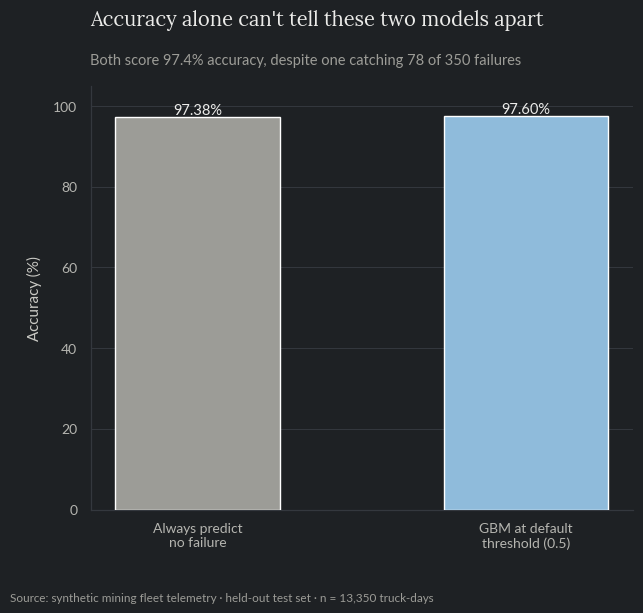

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ["Always predict\nno failure", "GBM at default\nthreshold (0.5)"]
vals = [naive_accuracy * 100, model_accuracy_at_default * 100]
ax.bar(bars, vals, color=[GREY, SLATE], width=0.5, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=10.5, color=INK)
ax.set_ylim(0, 105)
style_ax(ax, title="Accuracy alone can't tell these two models apart",
         subtitle=f"Both score {naive_accuracy:.1%} accuracy, despite one catching {tp_at_default} of {n_failures_test} failures",
         ylabel="Accuracy (%)")
add_footnote(fig, f"Source: synthetic mining fleet telemetry · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 5.** Accuracy of a trivial "always no failure" classifier vs. the trained GBM at the default 0.5 threshold.

The GBM's ranking is genuinely useful, section 4's PR-AUC and lift over the base rate prove that, but a 0.5 threshold on a model like this is functionally the same as not having a model at all (Figure 5). The threshold has to come from somewhere else.

## 6. Cost-based decision threshold

Missing an impending failure costs the truck's estimated downtime plus an extra $8,000 for an emergency repair. Flagging a truck for inspection that wasn't actually about to fail costs much less: a flat $4,000 maintenance-crew dispatch. Sweeping the threshold against total expected cost on the test set picks the operating point directly from those numbers instead of a default cutoff.

In [11]:
downtime_costs = test_df["downtime_cost_usd"].values
thresholds, costs, best_t = find_cost_optimal_threshold(y_test, y_prob_test, downtime_costs)
default_cost = costs[np.argmin(np.abs(thresholds - 0.5))]
best_cost = costs.min()
print(f"Cost-optimal threshold: {best_t:.2f}")
print(f"Expected cost at optimal threshold: ${best_cost:,.0f}")
print(f"Expected cost at naive t=0.50: ${default_cost:,.0f}")
print(f"Cost reduction: {(1 - best_cost / default_cost):.1%}")

Cost-optimal threshold: 0.05
Expected cost at optimal threshold: $8,698,814
Expected cost at naive t=0.50: $15,118,921
Cost reduction: 42.5%


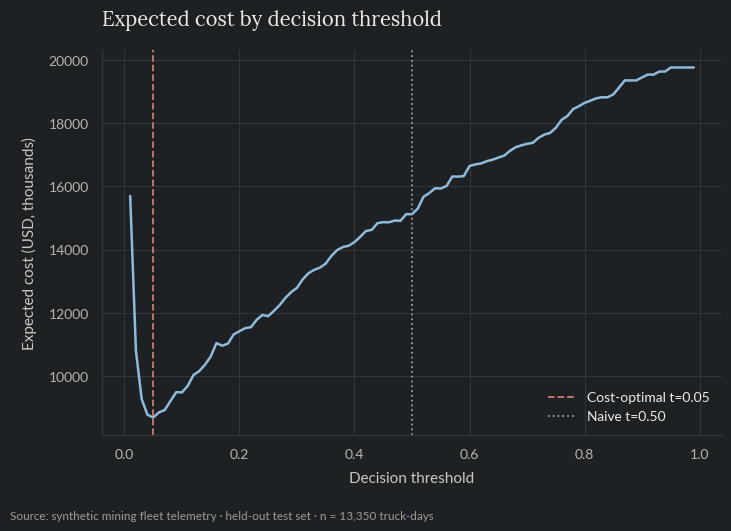

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs / 1000, color=SLATE, linewidth=1.8)
ax.axvline(best_t, ls="--", color=MUTED_RED, linewidth=1.3, label=f"Cost-optimal t={best_t:.2f}")
ax.axvline(0.50, ls=":", color=GREY, linewidth=1.3, label="Naive t=0.50")
style_ax(ax, title="Expected cost by decision threshold",
         xlabel="Decision threshold", ylabel="Expected cost (USD, thousands)", grid_axis="both")
ax.legend()
add_footnote(fig, f"Source: synthetic mining fleet telemetry · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 6.** Expected cost by decision threshold, cost-optimal threshold vs. the naive 0.5 cutoff.

In [13]:
y_pred_best = (y_prob_test >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
print(f"At t={best_t:.2f}: precision={precision:.4f}, recall={recall:.4f}")
print(cm)

At t=0.05: precision=0.2336, recall=0.7143
[[12180   820]
 [  100   250]]


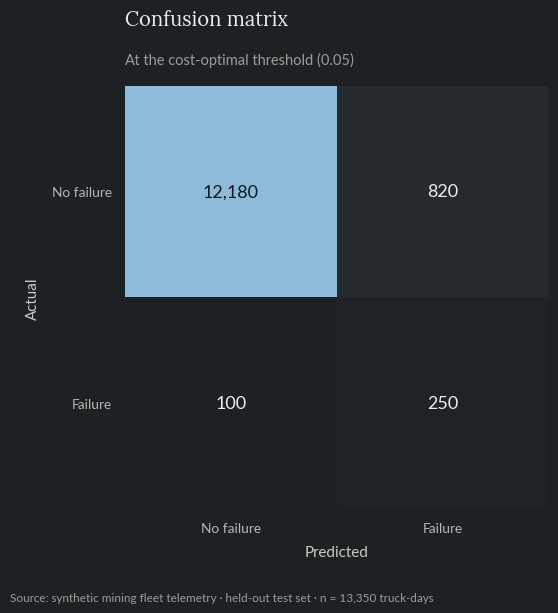

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap=HEATMAP_CMAP)
ax.set_xticks([0, 1]); ax.set_xticklabels(["No failure", "Failure"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No failure", "Failure"])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title="Confusion matrix", subtitle=f"At the cost-optimal threshold ({best_t:.2f})",
         xlabel="Predicted", ylabel="Actual", grid_axis=None)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color=HEATMAP_TEXT_HIGH if cm[i, j] > cm.max() / 2 else HEATMAP_TEXT_LOW)
add_footnote(fig, f"Source: synthetic mining fleet telemetry · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 7.** Confusion matrix at the cost-optimal threshold.

The cost-optimal threshold (0.05) sits well below 0.5 (Figure 6): the model flags a truck for inspection well before its predicted failure probability crosses a naive midpoint, catching about 71% of impending failures (recall 71.4%) at 23.4% precision (Figure 7), roughly 3 inspections for every real impending failure caught. That trade only makes sense because a missed failure costs so much more than an unnecessary inspection; a maintenance team that changed those cost assumptions would need to re-run this sweep, not eyeball a new threshold.

## 7. Interpretability (SHAP)

Tree SHAP (SHapley Additive exPlanations, adapted for tree-based models) attributes each individual prediction back to how much each feature pushed it up or down, checking whether the model actually recovered the risk drivers the label was generated from, or found some other pattern that happens to correlate with them in this particular sample.

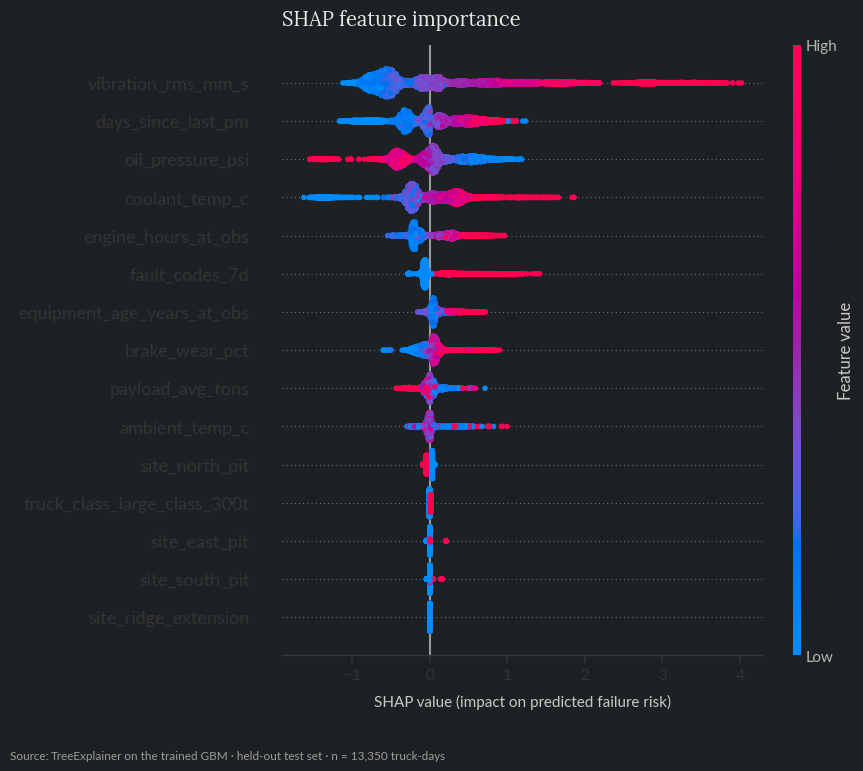

In [15]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer(X_test)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15, plot_size=None)
ax = plt.gca()
ax.set_title("SHAP feature importance", loc="left", fontsize=14.5, fontweight="normal",
             fontfamily="Lora", color=INK, pad=14)
ax.set_xlabel("SHAP value (impact on predicted failure risk)", fontsize=11, labelpad=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
add_footnote(fig, f"Source: TreeExplainer on the trained GBM · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 8.** SHAP feature importance on the held-out test set.

In [16]:
mean_abs = pd.Series(abs(shap_values.values).mean(axis=0), index=feature_names).sort_values(ascending=False)
mean_abs.head(10)

vibration_rms_mm_s            0.704012
days_since_last_pm            0.321009
oil_pressure_psi              0.294082
coolant_temp_c                0.274214
engine_hours_at_obs           0.228022
fault_codes_7d                0.122151
equipment_age_years_at_obs    0.101992
brake_wear_pct                0.093211
payload_avg_tons              0.058857
ambient_temp_c                0.047644
dtype: float64

SHAP recovers the intended ranking (Figure 8, table above): vibration dominates, followed by days since last PM, oil pressure, coolant temperature, and engine hours, the same signals the failure label in `src/generate_data.py` was actually built from. Fault codes and equipment age carry real but smaller signal, and brake wear, payload, and ambient temperature contribute the least among the numeric features, consistent with their smaller coefficients in the label-generating function. The categorical truck-class and site dummies contribute almost nothing individually, consistent with them not driving the label at all.

## 8. Unsupervised anomaly detection vs. a supervised model

Before enough confirmed-failure labels exist to train a model like the one above, or for a new truck class or fleet without failure history to learn from, a maintenance team has only unsupervised methods to fall back on. An Isolation Forest, fit on the same feature matrix with no access to `failure_within_7d` at all, works by randomly splitting the feature space over and over; an outlier tends to isolate into its own partition in far fewer splits than a typical point does, so a short average path length becomes the anomaly score. It scores each truck-day's general "unusualness" rather than its failure probability specifically.

In [17]:
iso = fit_isolation_forest(X_train)
iso_score = anomaly_scores(iso, X_test)
ap_iso = average_precision_score(y_test, iso_score)
lift_sup = ap / y_test.mean()
lift_iso = ap_iso / y_test.mean()
print(f"Supervised GBM: PR-AUC = {ap:.4f} ({lift_sup:.1f}x base rate)")
print(f"Isolation Forest: PR-AUC = {ap_iso:.4f} ({lift_iso:.1f}x base rate)")
print(f"Supervised advantage: {ap / ap_iso:.1f}x the unsupervised PR-AUC")

Supervised GBM: PR-AUC = 0.4019 (15.3x base rate)
Isolation Forest: PR-AUC = 0.2743 (10.5x base rate)
Supervised advantage: 1.5x the unsupervised PR-AUC


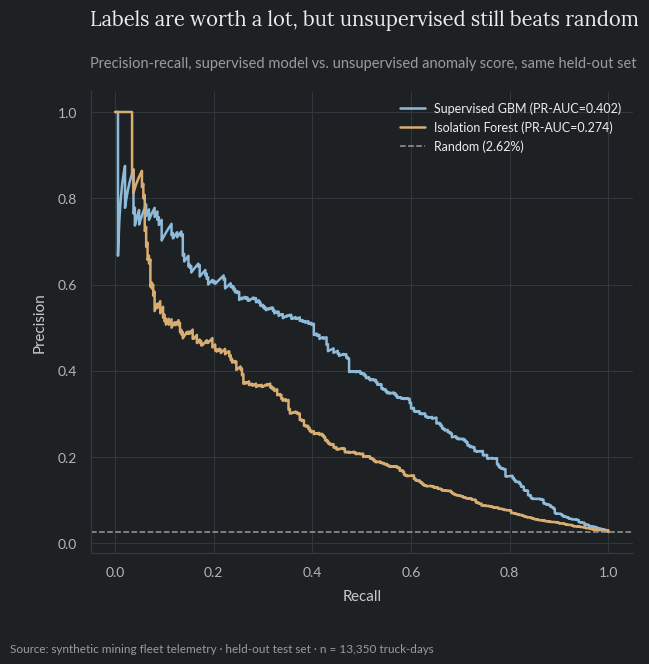

In [18]:
prec_iso, rec_iso, _ = precision_recall_curve(y_test, iso_score)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec, prec, color=SLATE, linewidth=1.8, label=f"Supervised GBM (PR-AUC={ap:.3f})")
ax.plot(rec_iso, prec_iso, color=MUTED_AMBER, linewidth=1.8, label=f"Isolation Forest (PR-AUC={ap_iso:.3f})")
ax.axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Random ({base_rate:.2%})")
style_ax(ax, title="Labels are worth a lot, but unsupervised still beats random",
         subtitle="Precision-recall, supervised model vs. unsupervised anomaly score, same held-out set",
         xlabel="Recall", ylabel="Precision", grid_axis="both")
ax.legend(loc="upper right", fontsize=9)
add_footnote(fig, f"Source: synthetic mining fleet telemetry · held-out test set · n = {len(test_df):,} truck-days")
plt.show()

**Figure 9.** Precision-recall curve, supervised GBM vs. unsupervised Isolation Forest, same held-out set.

The Isolation Forest clears random ranking by a wide margin (10.5x the base rate) and comes within 1.5x of the supervised model (15.3x), a much narrower gap than project 05's fraud case (4.2x). That difference makes sense given what each label actually looks like: a truck heading toward failure genuinely looks statistically unusual, elevated vibration, dropping oil pressure, rising coolant temperature, all at once, while a fraudulent transaction is deliberately built to resemble a genuine one. Equipment degradation is closer to true anomaly detection's home turf than fraud is, so unsupervised methods carry more of the weight here before labels exist.

## 9. Limitations

- Synthetic data with a hand-specified, mostly-linear risk function. Real equipment failure is more heterogeneous across failure modes (engine, transmission, hydraulics, tires) than this single-outcome label captures, and a real deployment would likely model each failure mode separately.
- The GBM's hyperparameters were hand-picked (a handful of configurations were compared on PR-AUC), not tuned via cross-validated search the way project 01's model was; a real deployment would run that search given how much PR-AUC moved across the depth/learning-rate/min-samples-leaf grid checked here.
- The cost assumptions ($8,000 emergency-repair charge, $4,000 inspection dispatch) are illustrative, not fit from real maintenance or operations data.
- The Isolation Forest was run with default-ish settings; more careful tuning (contamination rate, `n_estimators`, or a different unsupervised method entirely, like a local density estimator) might change the gap with the supervised model somewhat.
- No monitoring or drift-detection layer here, unlike project 01. Sensor calibration and duty cycles drift over a fleet's life in practice, so that would be one of the first things added in a real deployment of this model.